<a href="https://colab.research.google.com/github/tipismaca/Trabajo-Bebidas-del-Maipo-SA/blob/main/CasodeEstudio.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [40]:
!rm -rf Trabajo-Bebidas-del-Maipo-SA #lo que hace esta linea es que elimina la clonacion anterior (la con coma)
!git clone https://github.com/tipismaca/Trabajo-Bebidas-del-Maipo-SA.git

Cloning into 'Trabajo-Bebidas-del-Maipo-SA'...
remote: Enumerating objects: 94, done.
remote: Counting objects: 100% (94/94), done.
remote: Compressing objects: 100% (88/88), done.
remote: Total 94 (delta 39), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (94/94), 59.02 KiB | 1.18 MiB/s, done.
Resolving deltas: 100% (39/39), done.


In [41]:
import pandas as pd
import numpy as np
import json
import matplotlib.pyplot as plt

In [42]:
# 1. Definir la ruta base de la carpeta clonada
ruta_base = 'Trabajo-Bebidas-del-Maipo-SA/Datos_crudos/'

# 2. Leer los archivos CSV sin modificar los datos crudos originales
df_calidad = pd.read_csv(ruta_base + 'calidad_llenado.csv')
df_especificaciones = pd.read_csv(ruta_base + 'especificaciones_calidad.csv')

# 3. Agrupar por línea y formato como exige la Parte A
# Se calcula la media y el rango (máximo - mínimo) para cada subgrupo (n=5)
resumen_subgrupos = df_calidad.groupby(['linea', 'formato_L', 'subgrupo']).agg(
    media_volumen=('volumen_mL', 'mean'),
    rango_volumen=('volumen_mL', lambda x: np.ptp(x)) # np.ptp (peak-to-peak) calcula max - min
).reset_index()

# Mostrar las primeras filas para verificar que cargó y calculó bien
display(resumen_subgrupos.head())
display(df_especificaciones)

,linea,formato_L,subgrupo,media_volumen,rango_volumen
0,L1,0.5,1,501.560,4.01
1,L1,0.5,2,501.752,5.17
2,L1,0.5,3,503.630,4.13
3,L1,0.5,4,503.172,2.10
4,L1,0.5,5,503.396,8.49


,formato_L,nominal_mL,LIE_mL,LSE_mL,tolerancia_oiml_mL,limite_legal_inferior_mL
0,0.5,500.0,492.0,508.0,15.0,485.0
1,1.5,1500.0,1485.0,1515.0,22.5,1477.5
2,3.0,3000.0,2975.0,3025.0,45.0,2955.0


=== LÍMITES DE CONTROL FASE I (SEMANAS 1 A 6) ===
📍 L1 (0.5L) -> LCL: 500.24 mL | Media: 503.04 mL | UCL: 505.84 mL
📍 L2 (1.5L) -> LCL: 1497.88 mL | Media: 1504.74 mL | UCL: 1511.60 mL
📍 L2 (3.0L) -> LCL: 2997.10 mL | Media: 3008.68 mL | UCL: 3020.26 mL


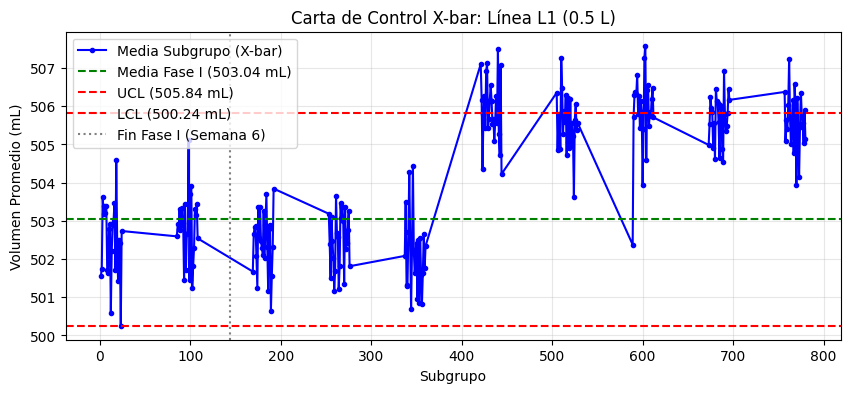

In [43]:
# 1. Definir la ruta base
ruta_base = 'Trabajo-Bebidas-del-Maipo-SA/Datos_crudos/'

# 2. Cargar archivos
df_llenado = pd.read_csv(ruta_base + 'calidad_llenado.csv')
df_especs = pd.read_csv(ruta_base + 'especificaciones_calidad.csv')
df_atributos = pd.read_csv(ruta_base + 'calidad_atributos.csv')

# 3. Agrupar subgrupos (n = 5)
subgrupos = df_llenado.groupby(['linea', 'formato_L', 'subgrupo']).agg(
    X_bar=('volumen_mL', 'mean'),
    R=('volumen_mL', lambda x: x.max() - x.min()),
    semana=('semana_registro', 'first'),
    turno=('turno', 'first')
).reset_index()

# Constantes para n = 5
A2, D3, D4, d2 = 0.577, 0.0, 2.114, 2.326

# 4. Fase I (Semanas 1 a 6)
fase1 = subgrupos[subgrupos['semana'] <= 6]

print("=== LÍMITES DE CONTROL FASE I (SEMANAS 1 A 6) ===")
limites_f1 = {}
for (linea, formato), g in fase1.groupby(['linea', 'formato_L']):
    X_db = g['X_bar'].mean()
    R_b = g['R'].mean()
    UCL_X, LCL_X = X_db + A2 * R_b, X_db - A2 * R_b
    limites_f1[(linea, formato)] = {'X_db': X_db, 'R_b': R_b, 'UCL_X': UCL_X, 'LCL_X': LCL_X, 'sigma_corto': R_b / d2}

    print(f"📍 {linea} ({formato}L) -> LCL: {LCL_X:.2f} mL | Media: {X_db:.2f} mL | UCL: {UCL_X:.2f} mL")

# 5. Gráfico de Carta X-bar para Línea L1 (0.5 L)
l1_data = subgrupos[(subgrupos['linea'] == 'L1') & (subgrupos['formato_L'] == 0.5)].sort_values('subgrupo')
lim_l1 = limites_f1[('L1', 0.5)]

plt.figure(figsize=(10, 4))
plt.plot(l1_data['subgrupo'], l1_data['X_bar'], marker='o', linestyle='-', color='b', markersize=3, label='Media Subgrupo (X-bar)')
plt.axhline(lim_l1['X_db'], color='green', linestyle='--', label=f"Media Fase I ({lim_l1['X_db']:.2f} mL)")
plt.axhline(lim_l1['UCL_X'], color='red', linestyle='--', label=f"UCL ({lim_l1['UCL_X']:.2f} mL)")
plt.axhline(lim_l1['LCL_X'], color='red', linestyle='--', label=f"LCL ({lim_l1['LCL_X']:.2f} mL)")
plt.axvline(x=144, color='gray', linestyle=':', label='Fin Fase I (Semana 6)')

plt.title('Carta de Control X-bar: Línea L1 (0.5 L)')
plt.xlabel('Subgrupo')
plt.ylabel('Volumen Promedio (mL)')
plt.legend(loc='upper left')
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
# PARTE A - PASO 2: APLICACIÓN DE REGLAS DE DECISIÓN (NELSON / WESTERN ELECTRIC)

# Re-agregamos el SKU al agrupamiento de subgrupos para el contraste de causas
subgrupos_det = df_llenado.groupby(['linea', 'formato_L', 'subgrupo']).agg(
    X_bar=('volumen_mL', 'mean'),
    R=('volumen_mL', lambda x: x.max() - x.min()),
    semana=('semana_registro', 'first'),
    turno=('turno', 'first'),
    sku=('sku', 'first')
).reset_index()

# Evaluaremos Regla 1 (Puntos fuera de UCL/LCL en X-bar) y Regla 4 (Puntos sobre UCL_R en R)
senales = []

for (linea, formato), g in subgrupos_det.groupby(['linea', 'formato_L']):
    lim = limites_f1[(linea, formato)]
    UCL_X, LCL_X = lim['UCL_X'], lim['LCL_X']
    UCL_R = D4 * lim['R_b']

    for idx, row in g.iterrows():
        # Regla 1: Fuera de límites en X-bar
        if row['X_bar'] > UCL_X or row['X_bar'] < LCL_X:
            senales.append({
                'Linea': linea,
                'Formato': f"{formato}L",
                'Subgrupo': row['subgrupo'],
                'Semana': row['semana'],
                'Turno': row['turno'],
                'SKU': row['sku'],
                'Regla': 'Regla 1 (Fuera de UCL/LCL en X-bar)',
                'Valor': round(row['X_bar'], 2)
            })

        # Regla 4: Inestabilidad en Rango (R > UCL_R)
        if row['R'] > UCL_R:
            senales.append({
                'Linea': linea,
                'Formato': f"{formato}L",
                'Subgrupo': row['subgrupo'],
                'Semana': row['semana'],
                'Turno': row['turno'],
                'SKU': row['sku'],
                'Regla': 'Regla 4 (Rango R excesivo)',
                'Valor': round(row['R'], 2)
            })

df_senales = pd.DataFrame(senales)

print("=== 1. SEÑALES DETECTADAS POR REGLA ===")
print(df_senales.groupby(['Linea', 'Formato', 'Regla']).size().reset_index(name='Total Señales'))

print("\n=== 2. CONTRASTE DE SEÑALES POR TURNO ===")
print(pd.crosstab(df_senales['Linea'], df_senales['Turno']))

print("\n=== 3. CONTRASTE DE SEÑALES POR PERÍODO (FASE I VS FASE II) ===")
df_senales['Fase'] = np.where(df_senales['Semana'] <= 6, 'Fase I (Sem 1-6)', 'Fase II (Sem 7-10)')
print(pd.crosstab(df_senales['Linea'], df_senales['Fase']))